©2026. For information, contact Deloitte Tohmatsu Group.

# 📝 演習概要

この演習では、scikit-learnを使った機械学習の基本的な分類タスクを体験します。Irisデータセットを読み込み、データの可視化・訓練/テスト分割・モデル学習・性能評価という一連の機械学習パイプラインを実装し、分類アルゴリズムの基本的な使い方を習得します。

# 事前準備

[JDLAが策定しているバージョン](https://www.jdla.org/certificate/engineer/)に合わせるために、以下のセルの実行をお願いします．

（#コメントアウト されているものは必要ありません）

また実行完了後に「ランタイムの再起動」をして下さい．

（以下のセルの実行は、最初にしていただければ、以降必要ありません．）


In [ ]:
%%capture
!pip uninstall matplotlib -y
!pip install matplotlib==3.9.3

# !pip uninstall opencv-python -y
# !pip install opencv-python==4.10.0.84

# !pip uninstall tensorflow -y
# !pip install tensorflow==2.18.0

# !pip uninstall torch -y
# !pip install torch==2.5.1

# !pip uninstall torchvision -y
# !pip install torchvision==0.20.1

## アヤメのデータセットの内容の可視化

# 機械学習

### アヤメのデータセットの読み込み

In [ ]:
from sklearn import datasets
iris = datasets.load_iris()

### データセットの情報を調べる

DESCR：データセットの説明<br>
data：説明変数（萼の縦幅 、萼の横幅、花弁の縦幅、花弁の横幅）の値<br>
Feature_names：'sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)’<br>
target：目的変数（どの品種か）の値（0,1,2）<br>
target_names：’setosa’、’versicolor’, 'virginica'<br>

In [ ]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

・予測するための入力情報をXとする。Xにiris.data（説明変数（萼の縦幅 、萼の横幅、花弁の縦幅、花弁の横幅）の値）を代入する。<br>
・教師データをyとする。yにiris.target（目的変数（どの品種か）の値（0,1,2））を代入する。<br>


In [ ]:
X = iris.data
y = iris.target

In [ ]:
X.shape

(150, 4)

In [ ]:
y.shape

(150,)

In [ ]:
# データの中身の確認
X[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [ ]:
y[:5]

array([0, 0, 0, 0, 0])

### データをプロットする

In [ ]:
# matplotlibのグラフ描画機能を利用するためのモジュールをインポート
# 通常、略称として「plt」とするのが慣例
import matplotlib.pyplot as plt

# Jupyter Notebook上でグラフをセル内に直接表示させるためのマジックコマンド
# Notebook環境専用の命令で、.pyファイルなどの通常のPythonスクリプトでは使用できない。
%matplotlib inline

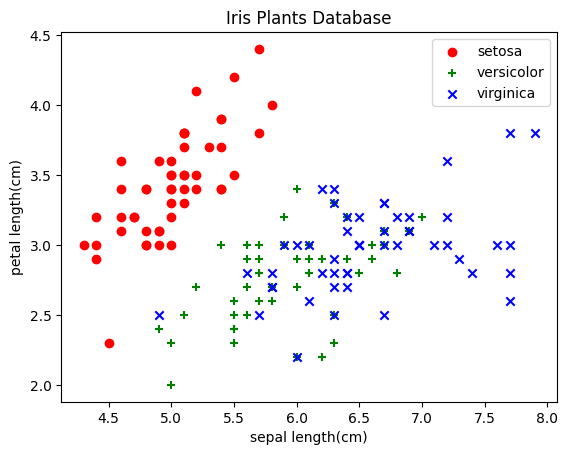

In [ ]:
# 0~50件目を赤色で表示
plt.scatter(X[:50, 0], X[:50, 1], color='r', marker='o', label='setosa')

# 51~100件目を緑色で表示
plt.scatter(X[50:100, 0], X[50:100, 1], color='g', marker='+', label='versicolor')

# 101件目～150件目を青色で表示
plt.scatter(X[100:, 0], X[100:, 1], color='b', marker='x', label='virginica')
plt.title("Iris Plants Database")
plt.xlabel("sepal length(cm)")
plt.ylabel("petal length(cm)")
plt.legend()   #凡例を付ける
plt.show()

### データを分割し、学習

In [ ]:
from sklearn import datasets
from sklearn import svm

# Irisデータセットの読み込み（scikit-learnに内蔵）
iris = datasets.load_iris()

# 特徴量（4次元: 花びらの長さ・幅など）をXに格納
X = iris.data

# 正解ラベル（0: setosa, 1: versicolor, 2: virginica）をyに格納
y = iris.target

# データ数の半分を訓練用、残り半分をテスト用に分割
n_train = len(X) // 2
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

# SVM（サポートベクターマシン）の分類器を定義（デフォルト：RBFカーネル）
clf = svm.SVC()

# 訓練データでモデルを学習
clf.fit(X_train, y_train)

SVC()

### テストデータで性能を検証する

In [ ]:
# テストデータを用いて学習済みモデルの精度（正解率）を評価
clf.score(X_test, y_test)

0.3333333333333333

## 🔧 実践問題1：`train_test_split` を使ってランダムフォレストで分類する

上のコードでは、データの前半と後半を手動で分割し、`svm.SVC()` で学習しました。
しかし実務では、以下の理由から `train_test_split` を使ってランダムに分割するのが一般的です。

- Irisデータはクラスごとに並んでいるため、**前半だけだと特定のクラスに偏る**
- `random_state` を指定することで**再現性を保ちつつランダム分割**できる

また、分類器もSVM以外にさまざまな選択肢があります。

| 分類器 | クラス名 | 特徴 |
|:---|:---|:---|
| 決定木 | `DecisionTreeClassifier` | 条件分岐で分類。解釈しやすいが過学習しやすい |
| ランダムフォレスト | `RandomForestClassifier` | 複数の決定木を組み合わせ。汎化性能が高い |
| k近傍法 | `KNeighborsClassifier` | 近くのデータ点で多数決。シンプルだがデータ量に弱い |

---

**問題：** 以下のコードの `______` を埋めて、`train_test_split` でデータを分割し、ランダムフォレストで学習・評価してください。

<br/>

<details>
<summary>💡 <b>ヒント（クリックして表示）</b></summary>

<blockquote>
上記の分類器はすべて <code>sklearn.ensemble</code> または <code>sklearn.tree</code> または <code>sklearn.neighbors</code> からインポートできます。<br>
どのモジュールに属するかは、クラス名から推測してみてください。
</blockquote>

</details>

<br/>


In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.______ import ______

# データ読み込み
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 訓練データとテストデータに分割
# テストデータの割合と乱数シードを設定してください
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=______, random_state=______
)

# 分類器を定義して学習
clf = ______(random_state=42)
clf.fit(______, ______)

# テストデータで精度を表示
print(f'テスト精度: {clf.score(X_test, y_test):.3f}')
print(f'学習データ数: {len(X_train)}, テストデータ数: {len(X_test)}')


<details><summary>解答例</summary>

```python
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

iris = datasets.load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

print(f'テスト精度: {clf.score(X_test, y_test):.3f}')
print(f'学習データ数: {len(X_train)}, テストデータ数: {len(X_test)}')
```

- `RandomForestClassifier` は `sklearn.ensemble` に属します（「アンサンブル」= 複数モデルの組み合わせ）
- `test_size=0.2` はデータの20%をテスト用にする設定です（0.2〜0.3が一般的）
- 手動分割（50/50）と比べてランダム分割はクラスの偏りが軽減されるため、より信頼性の高い評価ができます
- SVMの結果と精度を比べてみてください。ランダムフォレストは一般にチューニングなしでも高い精度が出やすいモデルです
</details>


## 🔧 実践問題2：特徴量の選択と分類レポートの出力

Irisデータセットには4つの特徴量がありますが、すべてが同じくらい分類に役立つわけではありません。

| インデックス | 特徴量名 | 概要 |
|:---:|:---|:---|
| 0 | sepal length | がく片の長さ |
| 1 | sepal width | がく片の幅 |
| 2 | petal length | 花びらの長さ |
| 3 | petal width | 花びらの幅 |

上の散布図を見ると、がく片（sepal）の特徴量だけではクラスが重なっている部分が多いことがわかります。
一方、花びら（petal）の特徴量はクラス間の分離がより明確です。

---

**問題：** 以下のコードの `______` を埋めて、**花びらの2特徴量（petal length, petal width）だけ**を使ってSVMで学習し、`classification_report` で品種ごとの精度を確認してください。

<br/>

<details>
<summary>💡 <b>ヒント（クリックして表示）</b></summary>

<blockquote>
NumPy配列から特定の列だけを取り出すには <code>X[:, [列1, 列2]]</code> のようにインデックスのリストを渡します。
</blockquote>

</details>

<br/>


In [ ]:
from sklearn import datasets, svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import ______  # 分類レポートを出力する関数

iris = datasets.load_iris()

# 花びら（petal）の特徴量だけを選択（インデックスを指定）
X_petal = iris.data[:, [______, ______]]
y = iris.target

# 分割して学習
X_train, X_test, y_train, y_test = train_test_split(
    X_petal, y, test_size=0.3, random_state=42
)

clf = svm.SVC(kernel='______')  # カーネルを指定して学習
clf.fit(X_train, y_train)

# 予測結果を取得して分類レポートを表示
y_pred = clf.______(X_test)
print(______(y_test, y_pred, target_names=iris.target_names))


<details><summary>解答例</summary>

```python
from sklearn import datasets, svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

iris = datasets.load_iris()

X_petal = iris.data[:, [2, 3]]  # petal length, petal width
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X_petal, y, test_size=0.3, random_state=42
)

clf = svm.SVC(kernel='rbf')  # RBFカーネル（デフォルト）
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=iris.target_names))
```

- petal length（インデックス2）と petal width（インデックス3）は品種間の差が大きく、**2特徴量だけでも高い分類精度**が得られます
- `classification_report` は precision（適合率）、recall（再現率）、f1-score をクラスごとに表示してくれるため、`score()` の正解率だけではわからない**クラスごとの性能差**が確認できます
- `kernel='rbf'` はSVMのデフォルトカーネルで、非線形な境界を学習できます。`'linear'` に変えるとどう変わるか試してみてください
</details>
